# Fase 4 — ARIMA / SARIMA

**Companion: Nielsen, cap. 6.** Aplicamos o ciclo Box-Jenkins ao IPCA usando os achados anteriores:

- Fase 3: IPCA em nível é estacionário ⇒ **d = 0**.
- Fase 2: há sazonalidade anual ⇒ vale testar termos **sazonais (período 12)**.

Selecionamos as ordens por AIC, diagnosticamos os resíduos (Ljung-Box) e prevemos 12 meses.

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

from series_eco.data import loaders
from series_eco.models import arima

ipca = loaders.load_panel("2000-01-01")["ipca"]
ipca.tail()

Date
2025-12-01    0.33
2026-01-01    0.33
2026-02-01    0.70
2026-03-01    0.88
2026-04-01    0.67
Freq: MS, Name: ipca, dtype: float64

## 1. Seleção por AIC (com sazonalidade)

Busca em grade sobre `p, q` (0–2) e termos sazonais `P, Q` (0–1), mantendo `d = 0` fixo (a diferenciação vem da Fase 3, não da busca por AIC).

In [2]:
sel = arima.auto_select(ipca, d=0, max_p=2, max_q=2, seasonal=True, seasonal_period=12)
print(f"order={sel.order}  seasonal_order={sel.seasonal_order}  AIC={sel.aic:.1f}")

order=(2, 0, 1)  seasonal_order=(1, 0, 1, 12)  AIC=139.6


## 2. Diagnóstico dos resíduos

Um bom modelo deixa resíduos sem autocorrelação (ruído branco). O teste de Ljung-Box com p-valor alto indica que a estrutura foi capturada.

Ljung-Box (24 lags): p=0.8537  ruído branco=True


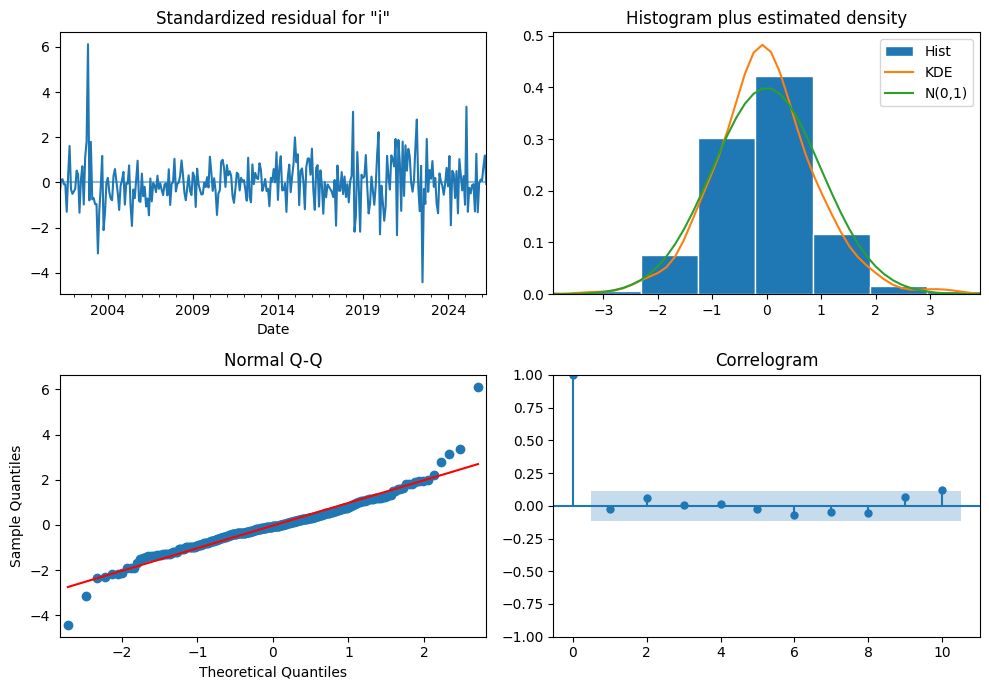

In [3]:
lb = arima.residual_ljung_box(sel.result, lags=24)
print(f"Ljung-Box (24 lags): p={lb.min_pvalue:.4f}  ruído branco={lb.is_white_noise}")
sel.result.plot_diagnostics(figsize=(10, 7))
plt.tight_layout()
plt.show()

## 3. Previsão de 12 meses

Projeção fora da amostra com intervalo de confiança de 95%.

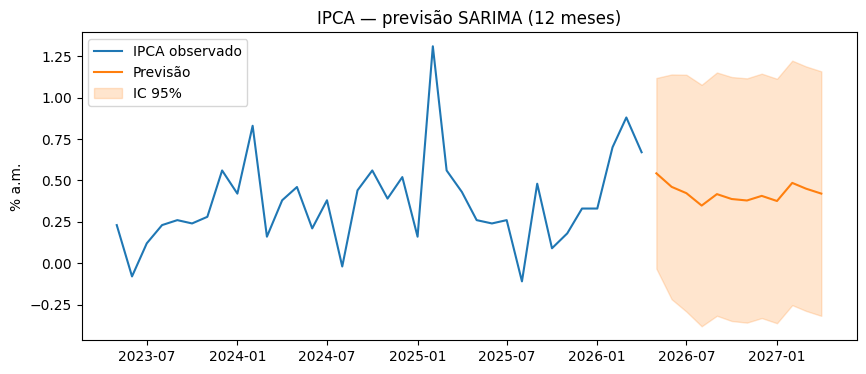

In [4]:
mean, ci = arima.forecast(sel.result, steps=12)
hist = ipca.iloc[-36:]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist.index, hist, label="IPCA observado")
ax.plot(mean.index, mean, color="C1", label="Previsão")
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="C1", alpha=0.2, label="IC 95%")
ax.set_title("IPCA — previsão SARIMA (12 meses)")
ax.set_ylabel("% a.m.")
ax.legend()
plt.show()

---
**Próximas fases:** Fase 5 traz câmbio e Selic como variáveis exógenas (VAR / Granger / ARIMAX) para ver se reduzem o erro; Fase 6 formaliza o backtesting walk-forward e compara este SARIMA contra baselines ingênuos (naïve e naïve sazonal) com teste de Diebold-Mariano.